
# Problem Statement
To develop an intelligent AI-powered assistant that can understand complete internal deployment-related PDF documents, including older RFC documents. The system should be able to process written content, structured tables, and images with valid content, and provide quick and accurate answers through natural language queries, reducing manual document review effort.


# Multi-modal RAG System

Many documents contain a mixture of content types, including text, tables and images.

Yet, information captured in images is lost in most RAG applications.

With the emergence of multimodal LLMs, like [GPT-4o-mini], it is worth considering how to utilize images in RAG Systems:

![](https://i.imgur.com/wcCDT38.gif)


---

* Use a multimodal LLM (such as [GPT-4o-mini], [LLaVA](https://llava.hliu.cc/), or [FUYU-8b](https://www.adept.ai/blog/fuyu-8b)) to produce text summaries from images and tables
* Embed and retrieve image, table and text summaries with a reference to the raw images and tables for given queries
* Pass raw images, tables and text chunks to a multimodal LLM for answer synthesis   

---



* We will use [Unstructured](https://unstructured.io/) to parse images, text, and tables from documents (PDFs).
* We will use the [multi-vector retriever](https://python.langchain.com/docs/modules/data_connection/retrievers/multi_vector) with [Chroma](https://www.trychroma.com/) and Redis to store raw text and images along with their summaries for retrieval.
* We will use GPT-4o-mini for both image summarization (for retrieval) as well as final answer synthesis from join review of images and texts (or tables).

In [ ]:
!unzip '/content/RFCdocs.zip'

## Install Dependencies

In [ ]:
!pip install "posthog<3.0.0"
!pip install posthog==2.4.2
!pip install -U chromadb posthog

In [ ]:
!pip install langchain==0.3.10

In [ ]:
!pip install langchain-openai==0.2.12

In [ ]:
!pip install langchain-community==0.3.11

In [ ]:
!pip install langchain-chroma==0.1.4

In [ ]:
!pip install redis==5.2.0

In [ ]:

!pip install "unstructured[pdf]==0.16.25"

In [ ]:
# install OCR dependencies for unstructured
!sudo apt-get install tesseract-ocr
!sudo apt-get install poppler-utils

In [ ]:
!pip install htmltabletomd==1.0.0

In [ ]:

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

## Data Loading & Processing

### Partition PDF tables, text, and images
  

In [ ]:
!pip install unstructured

In [ ]:
!pip install -U unstructured pdfminer.six pi-heif unstructured-inference
!pip install pdf2image
!pip install python-docx

In [ ]:
from langchain_community.document_loaders import DirectoryLoader,UnstructuredWordDocumentLoader
loader = DirectoryLoader(
    "/content/RFCdocs",
    glob="**/*.docx",
    loader_cls=UnstructuredWordDocumentLoader,
    loader_kwargs={
        "strategy": "hi_res",
        "extract_images_in_pdf": True,
        "infer_table_structure": True,
        "mode": "elements",
        "image_output_dir_path":"./RFCdocs"
    }
)
data = loader.load()



In [ ]:
[doc.metadata['category'] for doc in data if doc.metadata['category'] == 'Table']

In [ ]:
tables = [doc for doc in data if doc.metadata['category'] == 'Table']

In [ ]:
# Chunk text and extract text content

loader = DirectoryLoader(
    "/content/RFCdocs",
    glob="**/*.docx",
    loader_cls=UnstructuredWordDocumentLoader,
    loader_kwargs={
        "strategy": "hi_res",
        "extract_images_in_pdf": True,
        "infer_table_structure": True,
        "mode": "elements",
        "chunking_strategy" : "by_title", # section based chunking
        "max_characters" : 4000, #max size of chunks
        "new_after_n_chars" : 4000, #preferred sizeof chunks
        "combine_text_under_n_chars" : 2000, #smaller chunks < 2000 chars will be combined into a larger chunk
        "image_output_dir_path":"./RFCdocs"

    }
)

texts = loader.load()


In [ ]:
texts

In [ ]:
len(texts)

5

In [ ]:
data = texts + tables

In [ ]:
len(data)

27

In [ ]:
data[5]

Document(metadata={'source': '/content/RFCdocs/TfO AMT - Mob Deloyment Document_11Feb2026_Change1.docx', 'emphasized_text_contents': ['Title', 'Reference Number', 'File Name', 'Proprietary Notice', 'Copyright', 'Comments'], 'emphasized_text_tags': ['b', 'b', 'b', 'b', 'b', 'b'], 'file_directory': '/content/RFCdocs', 'filename': 'TfO AMT - Mob Deloyment Document_11Feb2026_Change1.docx', 'last_modified': '2026-02-18T02:48:49', 'page_number': 1, 'text_as_html': '<table><tr><td>Title</td><td>TfO AMT – Mob Deployment Document</td></tr><tr><td>Reference Number</td><td/></tr><tr><td>File Name</td><td/></tr><tr><td>Proprietary Notice</td><td>The ideas and designs set forth in this document and attachments are the property of Accenture plc, and are not to be disseminated, distributed, or otherwise conveyed to any third party without the prior written consent of Accenture. All Rights Reserved.</td></tr><tr><td>Copyright</td><td>© 2025 Accenture plc. All rights reserved. No part of this publicati

In [ ]:
from IPython.display import HTML, display, Markdown

In [ ]:
print(data[5].page_content)

Title TfO AMT – Mob Deployment Document Reference Number File Name Proprietary Notice The ideas and designs set forth in this document and attachments are the property of Accenture plc, and are not to be disseminated, distributed, or otherwise conveyed to any third party without the prior written consent of Accenture. All Rights Reserved. Copyright © 2025 Accenture plc. All rights reserved. No part of this publication may be reproduced, stored in a retrieval system, or transmitted in any form or by any means, electronic, mechanical, photo-copying, recording or otherwise without the prior permission of the copyright owner. Comments Location Edit new page and Actual finish date format under Execution & Monitoring page.


In [ ]:

data[5].metadata.get('text_as_html')

'<table><tr><td>Title</td><td>TfO AMT – Mob Deployment Document</td></tr><tr><td>Reference Number</td><td/></tr><tr><td>File Name</td><td/></tr><tr><td>Proprietary Notice</td><td>The ideas and designs set forth in this document and attachments are the property of Accenture plc, and are not to be disseminated, distributed, or otherwise conveyed to any third party without the prior written consent of Accenture. All Rights Reserved.</td></tr><tr><td>Copyright</td><td>© 2025 Accenture plc. All rights reserved. No part of this publication may be reproduced, stored in a retrieval system, or transmitted in any form or by any means, electronic, mechanical, photo-copying, recording or otherwise without the prior permission of the copyright owner.</td></tr><tr><td>Comments</td><td>Location Edit new page and Actual finish date format under Execution &amp; Monitoring page.</td></tr></table>'

In [ ]:
display(Markdown(data[7].metadata.get('text_as_html')))

<table><tr><td>Module</td><td>Deployment Required</td></tr><tr><td>Web configuration change</td><td>No</td></tr><tr><td>Database code change</td><td>No</td></tr><tr><td>Software upgradation</td><td>No</td></tr><tr><td>UI/API Code Change</td><td>Yes</td></tr></table>

In [ ]:
import htmltabletomd

md_table=htmltabletomd.convert_table(data[7].metadata.get('text_as_html'))
print(md_table)

| | |
| :--- | :--- |
| Module | Deployment Required |
| Web configuration change | No |
| Database code change | No |
| Software upgradation | No |
| UI/API Code Change | Yes |



Since unstructured extracts the text from the table without any borders, we can use the HTML text and put it directly in prompts (LLMs understand HTML tables well) or even better convert HTML tables to Markdown tables as below

## Separate Data into Text and Table Elements

In [ ]:
docs = []
tables = []

for doc in data:
    if doc.metadata['category'] == 'Table':
        tables.append(doc)
    elif doc.metadata['category'] == 'CompositeElement':
        docs.append(doc)

len(docs), len(tables)

(5, 22)

### Convert HTML Tables to Markdown

In [ ]:
for table in tables:
    table.page_content = htmltabletomd.convert_table(table.metadata['text_as_html'])

In [ ]:
for table in tables:
    print(table.page_content)
    print()

| | |
| :--- | :--- |
| Title | TfO AMT – Mob Deployment Document |
| Reference Number |  |
| File Name |  |
| Proprietary Notice | The ideas and designs set forth in this document and attachments are the property of Accenture plc, and are not to be disseminated, distributed, or otherwise conveyed to any third party without the prior written consent of Accenture. All Rights Reserved. |
| Copyright | © 2025 Accenture plc. All rights reserved. No part of this publication may be reproduced, stored in a retrieval system, or transmitted in any form or by any means, electronic, mechanical, photo-copying, recording or otherwise without the prior permission of the copyright owner. |
| Comments | Location Edit new page and Actual finish date format under Execution &amp; Monitoring page. |


| | | |
| :--- | :--- | :--- |
| Change Request No | Created by | Review By/Date |
|  | Divyangana.sharma |  |


| | |
| :--- | :--- |
| Module | Deployment Required |
| Web configuration change | No |
| Dat

### View Extracted Images

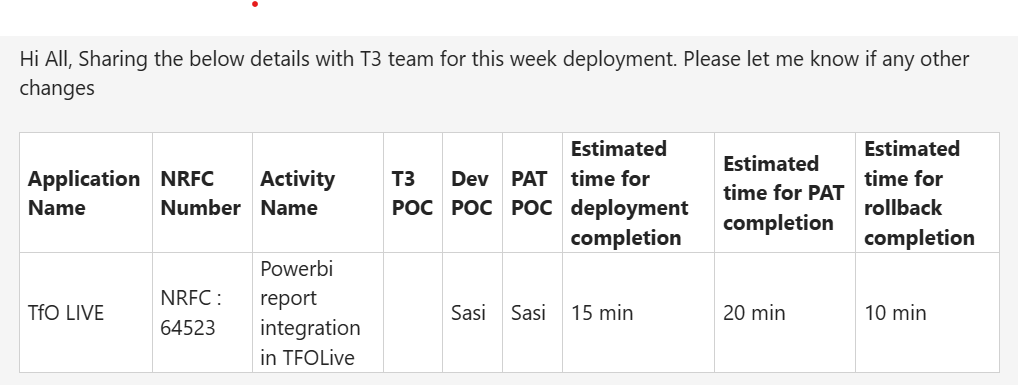

In [ ]:
from IPython.display import Image

Image('/content/RFCdocs/RFC3.png')

### Enter Open AI API Key and & Setup Environment Variables

In [ ]:
import os
from getpass import getpass
OPENAI_KEY = getpass('Enter Open AI API Key: ')
AZURE_OPENAI_ENDPOINT =  getpass('Enter AZURE_OPENAI_ENDPOINT: ')
os.environ['AZURE_OPENAI_API_KEY'] = OPENAI_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = AZURE_OPENAI_ENDPOINT

Enter Open AI API Key: ··········


### Load Connection to LLM

Here we create a connection to ChatGPT to use later in our chains

In [ ]:
from langchain_openai import AzureChatOpenAI
chatgpt = AzureChatOpenAI(
    azure_deployment="gpt-4o-mini",
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    api_version="2024-02-15-preview",
    temperature=0
)



### Text and Table summaries

We will use GPT-4o-mini to produce table and, text summaries.

Text summaries are advised if using large chunk sizes (e.g., as set above, we use 4k token chunks).

Summaries are used to retrieve raw tables and / or raw chunks of text.

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.runnables import RunnablePassthrough

# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text particularly for semantic retrieval.
These summaries will be embedded and used to retrieve the raw text or table elements
Give a detailed summary of the table or text below that is well optimized for retrieval.
For any tables also add in a one line description of what the table is about besides the summary.
Do not add redundant words like Summary.
Just output the actual summary content.

Table or text chunk:
{element}
"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
summarize_chain = (
                    {"element": RunnablePassthrough()}
                      |
                    prompt
                      |
                    chatgpt
                      |
                    StrOutputParser() # extracts the response as text and returns it as a string
)

# Initialize empty summaries
text_summaries = []
table_summaries = []

text_docs = [doc.page_content for doc in docs]
table_docs = [table.page_content for table in tables]

text_summaries = summarize_chain.batch(text_docs, {"max_concurrency": 5})
table_summaries = summarize_chain.batch(table_docs, {"max_concurrency": 5})

len(text_summaries), len(table_summaries)

(5, 22)

In [ ]:
text_summaries[0]

"TfO AMT (Mob) Deployment Document outlines the procedures and requirements for deploying the TfO AMT mobile application, including document control, deployment steps, and rollback procedures.\n\nThe document includes a proprietary notice from Accenture, emphasizing the confidentiality of its contents. It specifies that no web configuration or database code changes are required, but UI/API code changes are necessary for the location dropdown and delete functionality on the Execution & Monitoring page.\n\nKey links include the application URL and the Azure DevOps pipeline for deployment. Deployment steps involve selecting specific releases for both Mob-API and Mob-UI, with a note on updating release numbers during internal testing. Rollback steps are provided for reverting to previous releases if needed.\n\nDatabase deployment details include the production server's IP address and instructions for backing up stored procedures and tables related to the location delete functionality. The 

In [ ]:
table_summaries[19]

'This table outlines a change request with three columns: "Change Request No," "Created by," and "Review By/Date." Currently, the "Change Request No" and "Review By/Date" fields are empty, while the request was created by Anusha Seelam.'

### Image summaries

We will use [GPT-4o-mini] to produce the image summaries.

* We pass base64 encoded images

In [ ]:
import base64
import os

from langchain_core.messages import HumanMessage


def encode_image(image_path):
    """Getting the base64 string"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


def image_summarize(img_base64, prompt):
    """Make image summary"""
    chat =  AzureChatOpenAI(
    azure_deployment="gpt-4o-mini",
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    api_version="2024-02-15-preview",
    temperature=0
  )

    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content


def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval.
                Remember these images could potentially contain graphs, charts or tables also.
                These summaries will be embedded and used to retrieve the raw image for question answering.
                Give a detailed summary of the image that is well optimized for retrieval.
                Do not add additional words like Summary, This image represents, etc.
             """

    # Apply to images
    for img_file in sorted(os.listdir(path)):
        if img_file.endswith(".png"):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            img_base64_list.append(base64_image)
            image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries


# Image summaries
IMG_PATH = './RFCdocs'
imgs_base64, image_summaries = generate_img_summaries(IMG_PATH)

In [ ]:
len(imgs_base64), len(image_summaries)

(3, 3)

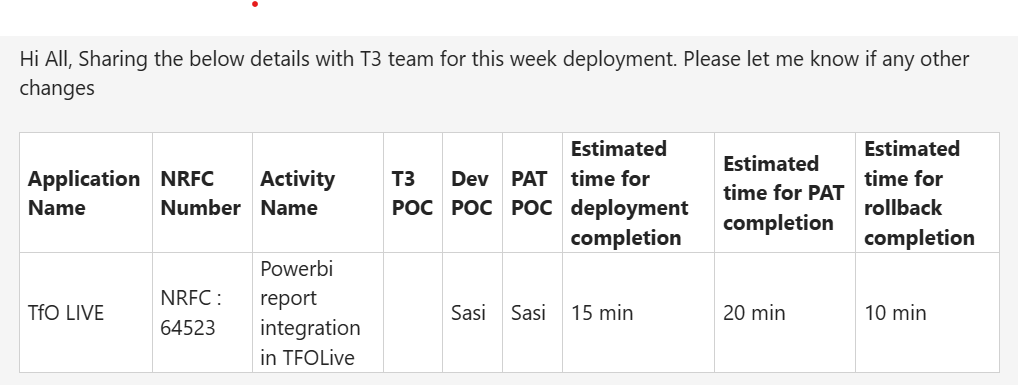

In [ ]:
display(Image('/content/RFCdocs/RFC3.png'))

In [ ]:
image_summaries[2]

'Table detailing deployment information for the T3 team. Columns include Application Name, NRFC Number, Activity Name, T3 POC, Dev POC, Estimated time for deployment completion, Estimated time for PAT completion, and Estimated time for rollback completion. The application listed is "TfO LIVE" with NRFC number "NRFC : 64523." The activity involves "Powerbi report integration in TFOLive." T3 POC is not specified, while Dev POC is "Sasi." Estimated times are 15 minutes for deployment completion, 20 minutes for PAT completion, and 10 minutes for rollback completion. A message at the top requests any changes to be communicated.'

## Multi-vector retriever

Use [multi-vector-retriever](https://python.langchain.com/docs/modules/data_connection/retrievers/multi_vector#summary) to index image (and / or text, table) summaries, but retrieve raw images (along with raw texts or tables).

### Download and Install Redis as a DocStore

You can use any other database or cache as a docstore to store the raw text, table and image elements

In [ ]:
%%sh
curl -fsSL https://packages.redis.io/gpg | sudo gpg --dearmor -o /usr/share/keyrings/redis-archive-keyring.gpg
echo "deb [signed-by=/usr/share/keyrings/redis-archive-keyring.gpg] https://packages.redis.io/deb $(lsb_release -cs) main" | sudo tee /etc/apt/sources.list.d/redis.list
sudo apt-get update  > /dev/null 2>&1
sudo apt-get install redis-stack-server  > /dev/null 2>&1
redis-stack-server --daemonize yes

deb [signed-by=/usr/share/keyrings/redis-archive-keyring.gpg] https://packages.redis.io/deb jammy main
Starting redis-stack-server, database path /var/lib/redis-stack


gpg: cannot open '/dev/tty': No such device or address
curl: (23) Failed writing body


### Open AI Embedding Models

LangChain enables us to access Open AI embedding models which include the newest models: a smaller and highly efficient `text-embedding-3-small` model, and a larger and more powerful `text-embedding-3-large` model.

In [ ]:
import os
from getpass import getpass
OPENAI_KEY = getpass('Enter Open AI API Key: ')
AZURE_OPENAI_ENDPOINT =  getpass('Enter AZURE_OPENAI_ENDPOINT: ')
os.environ['AZURE_OPENAI_API_KEY'] = OPENAI_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = AZURE_OPENAI_ENDPOINT

Enter Open AI API Key: ··········
Enter AZURE_OPENAI_ENDPOINT: ··········


In [ ]:

from langchain_openai import AzureOpenAIEmbeddings

openai_embed_model = AzureOpenAIEmbeddings(
    azure_deployment="text-embedding-3-small",
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    api_version="2024-02-15-preview",
)

In [ ]:
docs[0]

Document(metadata={'source': '/content/RFCdocs/TfO AMT - Mob Deloyment Document_11Feb2026_Change1.docx', 'emphasized_text_contents': ['TfO', 'AMT (Mob)', 'Deployment Document', 'Document Control', 'Title', 'Reference Number', 'File Name', 'Proprietary Notice', 'Copyright', 'Comments', 'Change Request No', 'Created by', 'Review By/Date', 'Module', 'Deployment Required', 'No', 'No', 'No', 'Yes', 'Description', ':', 'CR location dropdown', 'and', 'delete functionality in location edit', 'under Execution & Monitoring page', '.', 'Important Links', 'Application URL', 'https://', 'tfoamt.accenture.com/Mob', 'Deployment Steps:', 'TfOAMT_Portal_7310', 'TfO', '-DevOps-', 'AdvancedAnalytics', '-US', 'Organization', '.', 'Mob-API', 'Release –', '2', '11', 'Mob-UI', 'Release – 3', '5', '8', 'Note', ':', 'Release N', 'umber', 'change before deployment', 'as we keep on doing the internal testing,', 'will update during deployment.', 'RollBack', 'Steps:', 'TfOAMT_Portal_7310', 'TfO', '-DevOps-', 'Adva

### Add to vectorstore & docstore

Add raw docs and doc summaries to [Multi Vector Retriever](https://python.langchain.com/docs/modules/data_connection/retrievers/multi_vector#summary):

* Store the raw texts, tables, and images in the `docstore` (here we are using Redis).
* Store the texts, table summaries, and image summaries and their corresponding embeddings in the `vectorstore` (here we are using Chroma) for efficient semantic retrieval.
* Connect them using a common `document_id`

In [ ]:
import os
os.environ["ANONYMIZED_TELEMETRY"] = "false"

In [ ]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_community.storage import RedisStore
from langchain_community.utilities.redis import get_client
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings


def create_multi_vector_retriever(
    docstore, vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images
):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """


    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=docstore,
        id_key=id_key,
    )

    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):
        doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
        summary_docs = [
            Document(page_content=s, metadata={id_key: doc_ids[i]})
            for i, s in enumerate(doc_summaries)
        ]
        retriever.vectorstore.add_documents(summary_docs)
        retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

    # Add texts, tables, and images
    # Check that text_summaries is not empty before adding
    if text_summaries:
        add_documents(retriever, text_summaries, texts)
    # Check that table_summaries is not empty before adding
    if table_summaries:
        add_documents(retriever, table_summaries, tables)
    # Check that image_summaries is not empty before adding
    if image_summaries:
        add_documents(retriever, image_summaries, images)

    return retriever


# The vectorstore to use to index the summaries and their embeddings
chroma_db = Chroma(
    collection_name="mm_rag",
    embedding_function=openai_embed_model,
    collection_metadata={"hnsw:space": "cosine"},
)

# Initialize the storage layer - to store raw images, text and tables
client = get_client('redis://localhost:6379')
redis_store = RedisStore(client=client) # you can use filestore, memorystory, any other DB store also

# Create retriever
retriever_multi_vector = create_multi_vector_retriever(
    redis_store,
    chroma_db,
    text_summaries,
    text_docs,
    table_summaries,
    table_docs,
    image_summaries,
    imgs_base64,
)

In [ ]:
retriever_multi_vector

MultiVectorRetriever(vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x784a7e962f90>, docstore=<langchain_community.storage.redis.RedisStore object at 0x784a7e9579b0>, search_kwargs={})

## Test Multimodal RAG Retriever



In [ ]:
from IPython.display import HTML, display, Image
from PIL import Image
import base64
from io import BytesIO

def plt_img_base64(img_base64):
    """Disply base64 encoded string as image"""
    # Decode the base64 string
    img_data = base64.b64decode(img_base64)
    # Create a BytesIO object
    img_buffer = BytesIO(img_data)
    # Open the image using PIL
    img = Image.open(img_buffer)
    display(img)

### Check Retrieval

Examine retrieval; we get back images and tables also that are relevant to our question.

In [ ]:
query = "What is AIR ID for TfOLive application"
docs = retriever_multi_vector.invoke(query,limit=1)
len(docs)

4

In [ ]:
docs[0]

b'| | | | | | | |\n| :--- | :--- | :--- | :--- | :--- | :--- | :--- |\n| Sl. No | AIR ID | AIR ID | Parent Application | Child Application | URL (Prod Env) | Changes |\n| 1. | 1. | 5235 | TfOLive | TfOLive | https://tfolive.accenture.com/ | New functionality to create Forecast from Actuals \xe2\x80\x93 TAFT Screen Admin Fileupload |\n'

## Utilities to separate retrieved elements

We need to bin the retrieved doc(s) into the correct parts of the GPT-4o-mini prompt template.

Here we need to have text, table elements as one set of inputs and image elements as the other set of inputs as both require separate prompts in GPT-4o-mini.

In [ ]:
import re
import base64

def looks_like_base64(sb):
    """Check if the string looks like base64"""
    return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None


def is_image_data(b64data):
    """
    Check if the base64 data is an image by looking at the start of the data
    """
    image_signatures = {
        b"\xff\xd8\xff": "jpg",
        b"\x89\x50\x4e\x47\x0d\x0a\x1a\x0a": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }
    try:
        header = base64.b64decode(b64data)[:8]  # Decode and get the first 8 bytes
        for sig, format in image_signatures.items():
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False


def split_image_text_types(docs):
    """
    Split base64-encoded images and texts
    """
    b64_images = []
    texts = []
    for doc in docs:
        # Check if the document is of type Document and extract page_content if so
        if isinstance(doc, Document):
            doc = doc.page_content.decode('utf-8')
        else:
            doc = doc.decode('utf-8')
        if looks_like_base64(doc) and is_image_data(doc):
            b64_images.append(doc)
        else:
            texts.append(doc)
    return {"images": b64_images, "texts": texts}

In [ ]:
is_image_data(docs[1].decode('utf-8'))

True

In [ ]:
r = split_image_text_types(docs)
r

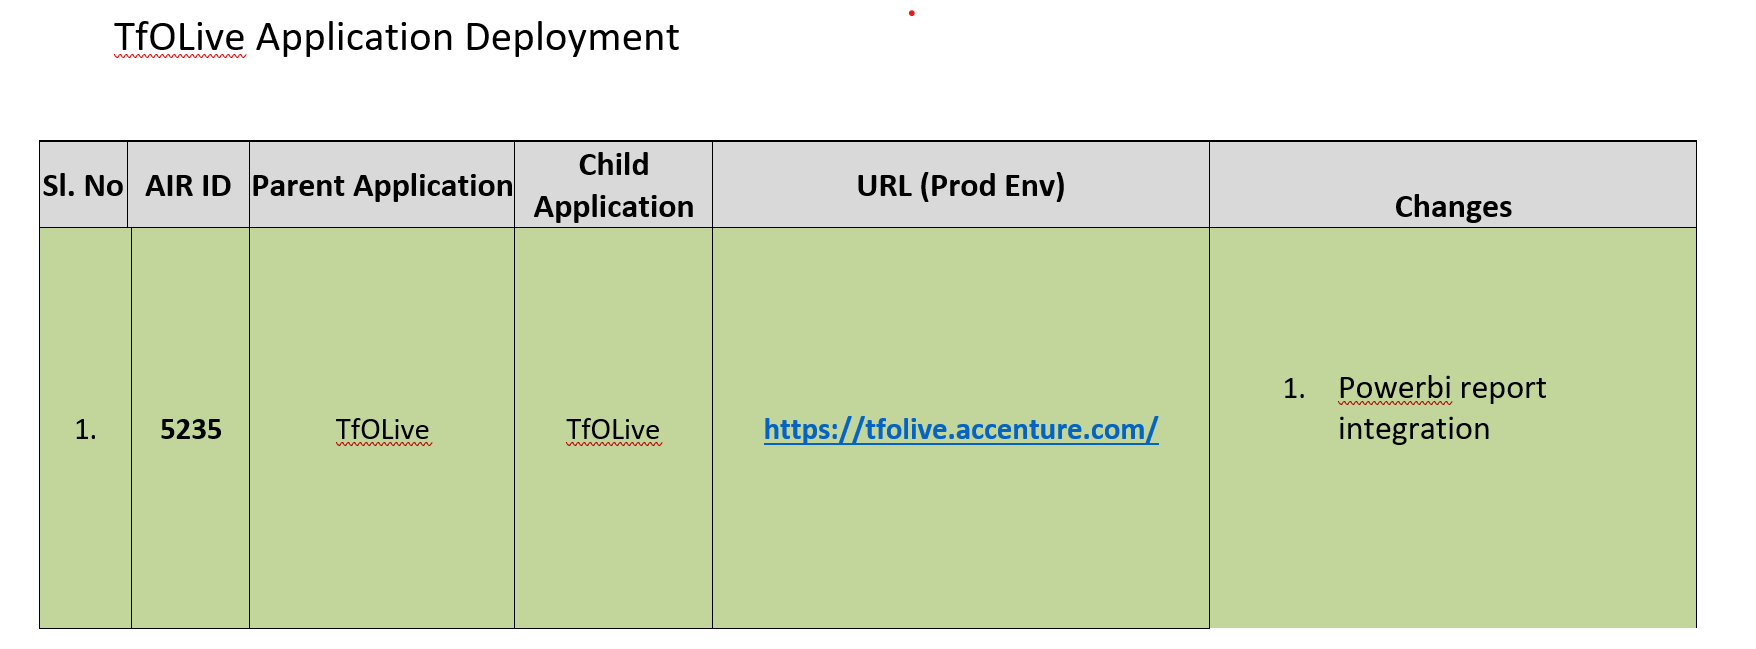

In [ ]:
plt_img_base64(r['images'][0])

## Multimodal RAG

### Build End-to-End Multimodal RAG Pipeline

Now let's connect our retriever, prompt instructions and build a multimodal RAG chain for generating the response basis the user asked question

In [ ]:
from operator import itemgetter
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.messages import HumanMessage

def multimodal_prompt_function(data_dict):
    """
    Create a multimodal prompt with both text and image context.

    This function formats the provided context from `data_dict`, which contains
    text, tables, and base64-encoded images. It joins the text (with table) portions
    and prepares the image(s) in a base64-encoded format to be included in a message.

    The formatted text and images (context) along with the user question are used to
    construct a prompt for GPT-4o-mini
    """
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Adding the text and tables for analysis
    # Augmentation steps
    text_message = {
        "type": "text",
        "text": (
            f"""

You are an **analyst** whose main goal is to carefully understand and explain information found in **text documents, data tables, and visual materials** such as **charts or graphs in images**.

You will receive **context information** below. This context may include a combination of:

* Written text or paragraphs
* Structured data in tables
* Images that contain charts, graphs, or any kind of visual data

Your task is to:

1. **Study all the provided materials together** — the text, tables, and images.
2. **Identify patterns, relationships, and trends** that can help answer the user’s question.
3. **Form your answer only from the given context.**

   * Do **not** guess or invent information.
   * If something is not mentioned or shown in the provided context, simply respond:
     *“I don’t know, because that information is not available in the given context. Please ask a question related to the provided data.”*

When writing your response:

* **Be as detailed as possible** and show your reasoning clearly.
* **Use simple, easy-to-understand language** so that anyone can follow your explanation.
* **Connect all the dots** between the text, tables, and charts logically and coherently.
* Present your answer in an **organized, thoughtful, and human-like way**, demonstrating deep understanding and analytical thinking.

Your overall goal is to give a **comprehensive, factual, and easy-to-follow explanation** using only the provided information.


                User question:
                {data_dict['question']}

                Context documents:
                {formatted_texts}

                Answer:

            """
        ),
    }
    messages.append(text_message)
    return [HumanMessage(content=messages)]


# Create RAG chain
multimodal_rag = (
        {
            "context": itemgetter('context'),
            "question": itemgetter('input'),
        }
            |
        RunnableLambda(multimodal_prompt_function)
            |
        chatgpt
            |
        StrOutputParser()
)

# Pass input query to retriever and get context document elements
retrieve_docs = (itemgetter('input')
                    |
                retriever_multi_vector
                    |
                RunnableLambda(split_image_text_types))

# Below, we chain `.assign` calls. This takes a dict and successively
# adds keys-- "context" and "answer"-- where the value for each key
# is determined by a Runnable (function or chain executing at runtime).
# This helps in also having the retrieved context along with the answer generated by GPT-4o
multimodal_rag_w_sources = (RunnablePassthrough.assign(context=retrieve_docs)
                                               .assign(answer=multimodal_rag)
)

In [ ]:
# Run RAG chain
query = "Tell me the activity planned on the NRFC number-64523"
response = multimodal_rag_w_sources.invoke({'input': query})
response

{'input': 'Tell me the activity planned on the NRFC number-64523',
 'context': {'images': ['...'],
  'texts': ['Infra\n\nDocument Control\n\nTitle Reachability Job issue fix Reference Number File Name Proprietary Notice The ideas and designs set forth in this document and attachments are the property of Accenture plc, and are not to be disseminated, distributed, or otherwise conveyed to any third party without the prior written consent of Accenture. All Rights Reserved. Copyright © 2025 Accenture plc. All rights reserved. No part of this publication may be reproduced, stored in a retrieval system, or transmitted in any form or by any means, electronic, mechanical, photocopying, recording or otherwise without the prior permission of the copyright owner. Comments Purpose –To get to know what was the issue , going to place the code in server and needs to debug\n\nWeb Deployment:\n\nChange Request No Created by Review By/Date Anusha.seelam\n\nModule Deployment Required Web configuration ch

In [ ]:
def multimodal_rag_qa(query):
    response = multimodal_rag_w_sources.invoke({'input': query})
    print('=='*50)
    print('Answer:')
    display(Markdown(response['answer']))
    print('--'*50)
    print('Sources:')
    text_sources = response['context']['texts']
    img_sources = response['context']['images']
    for text in text_sources:
        display(Markdown(text))
        print()
    for img in img_sources:
        plt_img_base64(img)
        print()
    print('=='*50)

Answer:


To renew the SSL certificate for the Techforops application, follow these steps:

1. **Download the Certificates**:
   - Access the file services at the specified path: 
     ```
     InternalToolsAndAutomation/Anusha/ssl.zip
     ```
   - Use the provided password to unzip the file (contact the relevant person for the password).

2. **Open Microsoft Management Console (MMC)**:
   - Go to **Start**, type **Run**, and press **OK**.
   - In the Run dialog, type **MMC** and press **OK**.

3. **Import the PFX File**:
   - In MMC, select **File** > **Add/Remove Snap-in**.
   - Choose **Certificates**, click **Add**, then **OK**.
   - Select **Computer account**, click **Next**, then **Finish** and **OK**.
   - Right-click on **Certificates** and select **Import**.
   - Browse to the location of the PFX file and enter the password used for exporting the certificate.

4. **Import the Intermediate Certificate**:
   - Navigate to the **Intermediate Certificates** section in MMC and import the intermediate certificate.

5. **Open Internet Information Services (IIS)**:
   - Select the DNS from the list of applications for which the certificate needs to be renewed.
   - Click on **Bindings**.

6. **Edit the HTTPS Binding**:
   - Select the application with HTTPS and click on **Edit**.
   - In the popup, choose the newly imported certificate that has a future expiration date and click **OK**.

7. **Verify the New Certificate**:
   - Click on **View** in the popup to check the details of the new certificate, ensuring it has been imported correctly.

8. **Post-Renewal Steps**:
   - Ensure that the application is functioning correctly by checking if the pages load fine in the Techforops application.

9. **Rollback Plan**:
   - If any issues arise, revert to the backup by pasting the files replaced during deployment from the backup folder.

By following these steps, you will successfully renew the SSL certificate for the Techforops application.

----------------------------------------------------------------------------------------------------
Sources:


Smcc Infra Deployment Document

Document Control

Purpose: To update the ssl certificate for techforopps application

Title Certificate Update of Techforops Application Document Reference Number File Name Proprietary Notice The ideas and designs set forth in this document and attachments are the property of Accenture plc, and are not to be disseminated, distributed, or otherwise conveyed to any third party without the prior written consent of Accenture. All Rights Reserved. Copyright © 2025 Accenture plc. All rights reserved. No part of this publication may be reproduced, stored in a retrieval system, or transmitted in any form or by any means, electronic, mechanical, photo-copying, recording or otherwise without the prior permission of the copyright owner. Comments

Change Request No Created by Review By/Date Anusha.seelam

Module Deployment Required Web configuration change No Database code change No Software upgradation No UI/API Code Change No

Description: Certificates needs to be updated for smcc infra and TfOLive applications.

Important Links

Application URL https://techforops.accenture.com/index.aspx

Servers to be Deployed:

Environment IP Address Server Name Production 2a02:ee80:421c:162::103 AZEWPAAWEB01_2a02ee80421c162103_ProdWEB

Deployment Steps:

Download the certificates from file services placed at this path.

InternalToolsAndAutomation/Anusha/ssl.zip

https://fileservices.accenture.com/app?operation=pubopp&id=1758520753275X288678876210000eQBDC

Use this password to unzip the file as shared by the team

Smcc: I will ping you personally

Open Server : Go to start Run and type MMC and Click on OK

You now, will need to import the pfx file using the Microsoft Management Console. This will be mapped to the website in IIS as well updated in the load balancer.

Select file then Add/Remove Snap in

Select certificates then add then OK

Now choose computer account then next

Select finish then OK.

Now Right-click and import the PFX by browsing file from the folder.

Key in the same password used for exporting the certificate

Next import the intermediate certificate by going to the Intermediate certificates.

Open Internet Information Services (IIS).

Select the DNS from list of applications for which certificate has to be renewed and then click on Bindings.

Select application with https and click on Edit.

Below popup will open with application details and Click on Select.

Below popup will open and then choose the certificate which is imported and has expiration date of future and then Click OK

Once clicked on View, below popup will open which will show the new certificate details which means new certificate is imported.

| | | | | |
| :--- | :--- | :--- | :--- | :--- |
| S. No | Sever Details | Deployment Steps | Post Deployment Testing steps | Rollback plan |
| 1 2 | i-00627-azep-tfolive-prod-01-sql-mi.e02f2b090d3a.database.windows.net Old Servers AWPTGPBPODB2_10.4.38.75 AWPTGPBPOWEB2_10.4.37.144 New Servers(IP): 2a02:ee80:421c:164::50 2a02:ee80:421c:162::103 | 1.Log in to the Data Base server 2.Take the backup of required scripts and place it in backup folder 3.Execute the deployment scripts in respective DB. 1.Log in to the Web server 2.Take the backup of required files and folders. 3.deploying the current deployment files is destination path | Check the TAFT -Forecast form Check if the pages are loading fine in TfOLive application | 1.Log in to the Data Base server 2.Execute the backup scripts from backup folder. Paste files which you replaced for deployment from backup folder if something is went wrong |


E:\AppFolders\Backups\Sasi_Backups\createafolderwithtodaysdate

Once we are ready with backups , we are good to paste deployment files(which is shared by Dev Team) and below are the steps.

For Change1:

copy the .cshtml file changes based on folder names on below path

E:\AppFolders\Web\Tfolive.accenture.com\Views\ForecastScreen\ForecastScreenMainPage

Copy dll in bin folder inside E:\AppFolders\Web\Tfolive.accenture.com\bin

Restart the tfolive.accenture.com application in iis

Output will looks like :

For Change2:

1.copy the .cshtml files based on folder names on below path

E:\AppFolders\Web\Tfolive.accenture.com\Views\Admin\

Copy dll in bin folder inside E:\AppFolders\Web\Tfolive.accenture.com\bin

2.Restart the tfolive.accenture.com application in iis

Backout plan

1.Paste files which you replaced for deployment from backup folder if something is went wrong

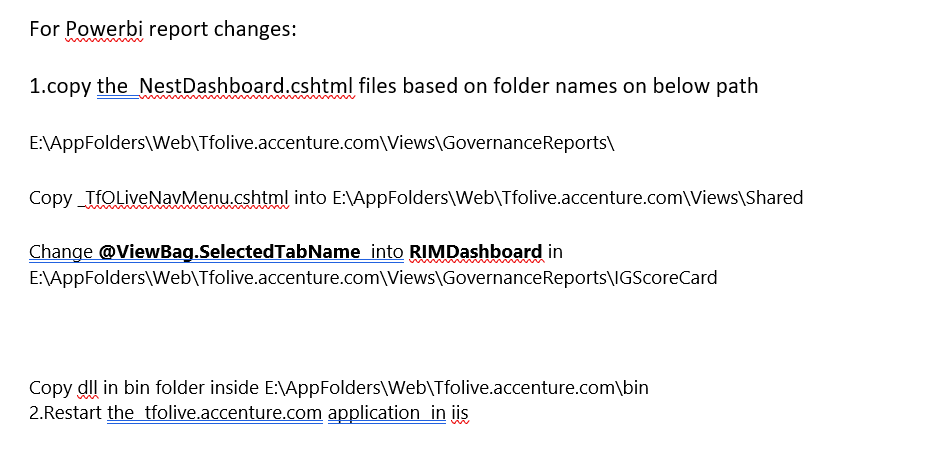

In [ ]:
query = "What are the steps to renewal the ssl certificate"
multimodal_rag_qa(query)